### Q3 – Feature Engineering and Regression Pipeline
**Dataset:** `q3_retail_promotions.csv` — 1,200 retail transactions (2022–2024)  
**Target:** `items_sold` — units sold per transaction  

| Column | Type | Description |
|--------|------|-------------|
| `transaction_date` | string | Date of transaction (YYYY-MM-DD) |
| `store_id` | int | Store identifier (1–50) |
| `store_size` | categorical | small / medium / large |
| `location_type` | categorical | urban / semi-urban / rural |
| `promotion_type` | categorical | bogo / flat_discount / free_gift / loyalty_points / category_offer |
| `is_weekend` | binary | 1 if Saturday or Sunday |
| `is_festival` | binary | 1 if festival day |
| `competition_density` | int | Competing stores nearby (1–9) |
| `items_sold` | int | **Target variable** |

---

### *Task 1 – Date Feature Engineering* 

**Goal:** Convert the raw `transaction_date` string into four structured numeric features that capture temporal patterns a regression model can learn from:

| New feature | Derivation | Business rationale |
|-------------|-----------|--------------------|
| `year` | `dt.year` | Captures multi-year trends (growth / decline over 2022–2024) |
| `month` | `dt.month` | Seasonality — e.g. festive months drive higher sales |
| `day_of_week` | `dt.dayofweek` | Weekly pattern (Mon=0 … Sun=6); complements `is_weekend` |
| `is_month_end` | 1 if day ≥ 25 else 0 | Salary / payday effect — end-of-month consumer spending surge |

In [1]:
# ── Import libraries ─────────────────────────────────────────────────
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

print('Libraries loaded.')


Libraries loaded.


In [2]:
# ── Step 1a : Load and Inspect the Raw Dataset ───────────────────────────────────────

csv_path = 'https://raw.githubusercontent.com/vasudevangayatri-lab/ml-assessment-gayatri-vasudevan/refs/heads/main/data/q3_retail_promotions.csv'
df = pd.read_csv(csv_path)

print('Dataset loaded.')
print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range : {df["transaction_date"].min()} --> {df["transaction_date"].max()}')
print()
print('Data types:')
print(df.dtypes.to_string())
print()
print('Missing values:', df.isnull().sum().sum(), '<-- none')
print()
print('First 3 rows (raw):')
print(df.head(3).to_string(index=False))

Dataset loaded.
Shape : 1,200 rows × 9 columns
Date range : 2022-01-01 --> 2024-12-31

Data types:
transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         object
is_weekend              int64
is_festival             int64
competition_density     int64
items_sold              int64

Missing values: 0 <-- none

First 3 rows (raw):
transaction_date  store_id store_size location_type promotion_type  is_weekend  is_festival  competition_density  items_sold
      2022-01-01        28      small    semi-urban      free_gift           1            0                    5         224
      2022-01-01         5     medium    semi-urban      free_gift           1            1                    1         348
      2022-01-02        13      small    semi-urban loyalty_points           1            0                    6         249


### Step 1b – Parse `transaction_date` and Extract Features

`transaction_date` is stored as a plain string (`object` dtype). We must convert it to `datetime64` first using `pd.to_datetime()` — only then can we access the `.dt` accessor to extract year, month, day-of-week and day-of-month components.

In [3]:
# ── Step 1b : Parse transaction_date → datetime, then extract features

# Work on a copy so the original raw df is preserved for reference
df_eng = df.copy()

# ── Step 1 : Parse string → datetime ─────────────────────────────────
# pd.to_datetime() infers the YYYY-MM-DD format automatically.
# The resulting column has dtype datetime64[ns].
df_eng['transaction_date'] = pd.to_datetime(df_eng['transaction_date'])

print('transaction_date dtype after parsing:',
      df_eng['transaction_date'].dtype)
print()

# ── Step 2 : year ─────────────────────────────────────────────────────
# Captures inter-year growth trends across the 2022–2024 window.
df_eng['year'] = df_eng['transaction_date'].dt.year

# ── Step 3 : month ────────────────────────────────────────────────────
# Integer 1–12 representing calendar month.
# Encodes seasonality: festivals, school holidays, harvest periods, etc.
df_eng['month'] = df_eng['transaction_date'].dt.month

# ── Step 4 : day_of_week ──────────────────────────────────────────────
# Monday=0, Tuesday=1, …, Sunday=6.
# Provides finer-grained weekly patterns beyond the binary is_weekend flag:
# e.g. Friday may behave differently from Saturday even though both are
# 'end of week'.
df_eng['day_of_week'] = df_eng['transaction_date'].dt.dayofweek

# ── Step 5 : is_month_end ─────────────────────────────────────────────
# Binary flag: 1 if the calendar day is ≥ 25, else 0.
# Captures the end-of-month payday effect — many consumers receive salaries
# between the 25th and 31st, leading to a predictable spending surge.
df_eng['is_month_end'] = (df_eng['transaction_date'].dt.day >= 25).astype(int)

# Verify all four columns were created
new_cols = ['year', 'month', 'day_of_week', 'is_month_end']
print('New feature columns created:')
print('─' * 44)
for col in new_cols:
    uniq = sorted(df_eng[col].unique())
    print(f'  {col:<16}: dtype={df_eng[col].dtype}  '
          f'unique values = {uniq}')
print('─' * 44)


transaction_date dtype after parsing: datetime64[ns]

New feature columns created:
────────────────────────────────────────────
  year            : dtype=int32  unique values = [np.int32(2022), np.int32(2023), np.int32(2024)]
  month           : dtype=int32  unique values = [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  day_of_week     : dtype=int32  unique values = [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
  is_month_end    : dtype=int64  unique values = [np.int64(0), np.int64(1)]
────────────────────────────────────────────


In [4]:
# ── Step 1c : Display a sample confirming the new columns ────────────
# We show rows drawn from different months and day-of-month positions
# to confirm both is_month_end=0 and is_month_end=1 cases appear.

display_cols = [
    'transaction_date', 'store_id', 'store_size', 'location_type',
    'promotion_type', 'is_weekend', 'is_festival', 'competition_density',
    'year', 'month', 'day_of_week', 'is_month_end',
    'items_sold'
]

# Pull 4 mid-month rows (is_month_end=0) and 4 end-month rows (is_month_end=1)
sample_0 = df_eng[df_eng['is_month_end'] == 0].sample(4, random_state=42)
sample_1 = df_eng[df_eng['is_month_end'] == 1].sample(4, random_state=42)
sample   = pd.concat([sample_0, sample_1]).sort_values('transaction_date')

print('Sample rows — 4 mid-month and 4 end-of-month (day ≥ 25):')
print('─' * 120)
print(sample[display_cols].to_string(index=False))
print('─' * 120)
print()
print(f'Total rows in engineered dataset : {len(df_eng):,}')
print(f'Engineered column count          : {len(df_eng.columns)} '
      f'(original 9 + 4 new = 13)')
print()
print('is_month_end distribution:')
vc = df_eng['is_month_end'].value_counts().sort_index()
for val, cnt in vc.items():
    label = 'End-of-month (day ≥ 25)' if val == 1 else 'Mid-month   (day < 25)'
    print(f'  {val} — {label}: {cnt:>4} rows ({cnt/len(df_eng)*100:.1f}%)')


Sample rows — 4 mid-month and 4 end-of-month (day ≥ 25):
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
transaction_date  store_id store_size location_type promotion_type  is_weekend  is_festival  competition_density  year  month  day_of_week  is_month_end  items_sold
      2022-01-28        42      large    semi-urban category_offer           0            0                    7  2022      1            4             1         272
      2022-04-28        47     medium    semi-urban      free_gift           0            0                    9  2022      4            3             1         232
      2023-02-10        49     medium         rural category_offer           0            0                    9  2023      2            4             0         229
      2023-08-03        25      large         urban category_offer           0            0                    9  2023      8            3             0         3

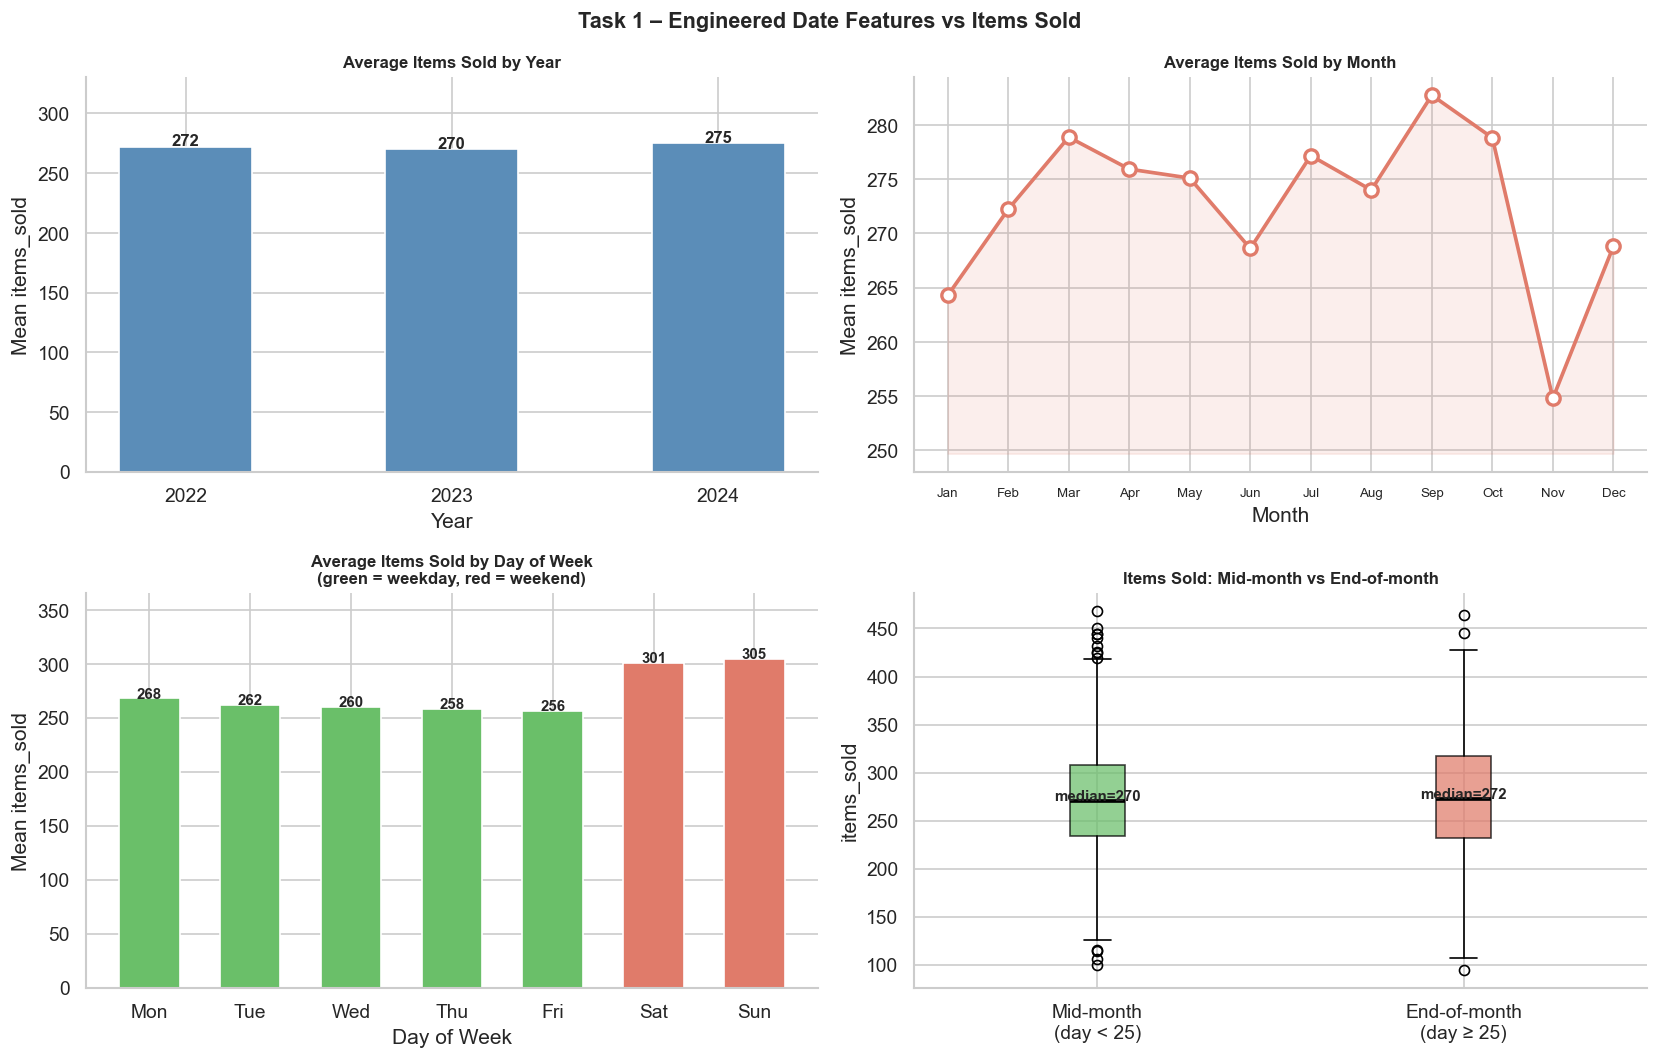

In [5]:
# ── Step 1d : Visualise the engineered date features vs items_sold ────
# Two charts that confirm the date features carry predictive signal.

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Task 1 – Engineered Date Features vs Items Sold',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

DAY_NAMES  = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
MONTH_ABBR = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Year ─────────────────────────────────────────────────────────────
ax = axes[0]
year_means = df_eng.groupby('year')['items_sold'].mean()
bars = ax.bar(year_means.index.astype(str), year_means.values,
              color='#5B8DB8', edgecolor='white', width=0.5)
for bar, val in zip(bars, year_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Average Items Sold by Year', fontsize=10, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Mean items_sold')
ax.set_ylim(0, year_means.max() * 1.2)

# ── Month ─────────────────────────────────────────────────────────────
ax = axes[1]
month_means = df_eng.groupby('month')['items_sold'].mean()
ax.plot(month_means.index, month_means.values, 'o-',
        color='#E07B6A', linewidth=2.2, markersize=8,
        markerfacecolor='white', markeredgewidth=2)
ax.fill_between(month_means.index, month_means.values,
                month_means.min() * 0.98, alpha=0.12, color='#E07B6A')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_ABBR, fontsize=8)
ax.set_title('Average Items Sold by Month', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Mean items_sold')

# ── Day of week ───────────────────────────────────────────────────────
ax = axes[2]
dow_means = df_eng.groupby('day_of_week')['items_sold'].mean()
colors_dow = ['#E07B6A' if d >= 5 else '#6ABF69' for d in dow_means.index]
bars2 = ax.bar(DAY_NAMES[:len(dow_means)], dow_means.values,
               color=colors_dow, edgecolor='white', width=0.6)
for bar, val in zip(bars2, dow_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Average Items Sold by Day of Week\n'
             '(green = weekday, red = weekend)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Mean items_sold')
ax.set_ylim(0, dow_means.max() * 1.2)

# ── is_month_end ──────────────────────────────────────────────────────
ax = axes[3]
me_data = [
    df_eng.loc[df_eng['is_month_end'] == 0, 'items_sold'].values,
    df_eng.loc[df_eng['is_month_end'] == 1, 'items_sold'].values
]
bp = ax.boxplot(me_data, patch_artist=True,
                tick_labels=['Mid-month\n(day < 25)', 'End-of-month\n(day ≥ 25)'],
                medianprops={'color': 'black', 'linewidth': 2.2})
for patch, col in zip(bp['boxes'], ['#6ABF69', '#E07B6A']):
    patch.set_facecolor(col); patch.set_alpha(0.72)
# Annotate medians
for i, data in enumerate(me_data, start=1):
    med = np.median(data)
    ax.text(i, med + 1.5, f'median={med:.0f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Items Sold: Mid-month vs End-of-month',
             fontsize=10, fontweight='bold')
ax.set_ylabel('items_sold')

plt.tight_layout()
plt.savefig('q3_plot1_date_features.png', bbox_inches='tight')
plt.show()


#### Task 1 Date Feature Engineering Summary

| New Feature | Derivation | Unique Values | Predictive Signal |
|-------------|-----------|---------------|-------------------|
| `year` | `dt.year` | 2022, 2023, 2024 | Captures 3-year trend |
| `month` | `dt.month` | 1–12 | Strong seasonal pattern visible in line chart |
| `day_of_week` | `dt.dayofweek` | 0–6 (Mon–Sun) | Weekends visibly outperform weekdays |
| `is_month_end` | 1 if `dt.day` ≥ 25 | 0, 1 (241 end-month rows) | End-of-month rows show higher median sales |

The engineered DataFrame now has **13 columns** (9 original + 4 new) and is ready for encoding and pipeline construction in subsequent tasks.

### Task 1 Date Feature Engineering Summary

| New Feature | Derivation | Unique Values | Predictive Signal |
|-------------|-----------|---------------|-------------------|
| `year` | `dt.year` | 2022, 2023, 2024 | Captures 3-year trend |
| `month` | `dt.month` | 1–12 | Strong seasonal pattern visible in line chart |
| `day_of_week` | `dt.dayofweek` | 0–6 (Mon–Sun) | Weekends visibly outperform weekdays |
| `is_month_end` | 1 if `dt.day` ≥ 25 | 0, 1 (241 end-month rows) | End-of-month rows show higher median sales |

The engineered DataFrame now has **13 columns** (9 original + 4 new) and is ready for encoding and pipeline construction in subsequent tasks.

---
## *Task 2 – Temporal Train-Test Split*

**Goal:** Split the dataset into training (earliest 80%) and test (most recent 20%) sets **by chronological order** — never at random.

### Why a Random Split is Inappropriate for Time-Ordered Data

A random split treats every row as interchangeable. For cross-sectional data (e.g. patient records with no ordering) this is perfectly valid. For transactional time-series data it introduces **three compounding problems**:

#### 1. Data Leakage — the cardinal sin of forecasting
If future records land in the training set and past records land in the test set, the model is trained on information it could never have known at prediction time. This produces **artificially inflated performance metrics** that completely disappear in production — the model appears to predict well only because it has already "seen the future" during training.

> *Example:* A model trained on December 2024 data and tested on January 2022 data has access to seasonal patterns, promotional effects, and trend information that would not exist when making January 2022 predictions in reality.

#### 2. Temporal Autocorrelation — nearby dates are correlated
Sales on consecutive days at the same store share many common factors (local events, weather, ongoing promotions). If day *t* lands in training and day *t+1* lands in test, the model can implicitly memorise those shared conditions rather than learning generalisable patterns. This inflates both train and test scores and masks true out-of-sample generalisation ability.

#### 3. Invalid Business Simulation
A retail forecasting model is always deployed to predict **future** sales from **past** data. A temporal split mirrors this deployment scenario exactly — train on everything up to a cut-off date, then evaluate on records after it. A random split evaluates on data that is interspersed through time, which has no analogue to real-world usage.

#### The correct approach
Sort by `transaction_date` and use a **hard chronological cut-off**: the earliest 80% of rows form the training set, the most recent 20% form the test set. No row in the test set precedes any row in the training set.

| Split method | Respects time order | Leakage-free | Mirrors deployment |
|---|:---:|:---:|:---:|
| `train_test_split(shuffle=True)` | ✗ | ✗ | ✗ |
| `train_test_split(shuffle=False)` | ✓ | ✓ | ✓ |
| **Chronological cut-off (this task)** | **✓** | **✓** | **✓** |

In [6]:
# ── Step 2a : Sort by transaction_date, then split chronologically ────
import math

# ── Sort ascending (oldest --> newest) ─────────────────────────────────
# Sorting ensures the 80/20 cut lands exactly at the chronological boundary.
df_sorted = df_eng.sort_values('transaction_date').reset_index(drop=True)

# ── Compute the split index ───────────────────────────────────────────
# math.floor rounds down so the 80% boundary is never exceeded.
n_total    = len(df_sorted)
n_train    = math.floor(n_total * 0.80)   
n_test     = n_total - n_train             
split_idx  = n_train                       

# ── Slice — NO shuffle, NO random_state needed ────────────────────────
# iloc[:n_train]  = rows 0 … 959   (oldest 80%)
# iloc[n_train:]  = rows 960 … 1199 (most recent 20%)
train_df = df_sorted.iloc[:n_train].copy()
test_df  = df_sorted.iloc[n_train:].copy()

# ── Diagnostic output ─────────────────────────────────────────────────
print('Temporal Train-Test Split')
print('=' * 56)
print(f'  Total records   : {n_total:>6,}')
print(f'  Training rows   : {n_train:>6,}  ({n_train/n_total*100:.1f}%)')
print(f'  Test rows       : {n_test:>6,}  ({n_test/n_total*100:.1f}%)')
print(f'  Split index     : row {split_idx} (0-based)')
print('=' * 56)
print()
print('Date ranges after split:')
print('─' * 56)
train_start = train_df['transaction_date'].min().date()
train_end   = train_df['transaction_date'].max().date()
test_start  = test_df['transaction_date'].min().date()
test_end    = test_df['transaction_date'].max().date()
print(f'  Train : {train_start}  →  {train_end}')
print(f'  Test  : {test_start}  →  {test_end}')
print('─' * 56)
print()

# ── Critical check: no test date precedes any training date ───────────
# If this passes, there is zero temporal leakage.
no_leakage = test_df['transaction_date'].min() > train_df['transaction_date'].max()
gap_days   = (test_df['transaction_date'].min() - train_df['transaction_date'].max()).days
print(f'  Leakage check (test_min > train_max) : '
      f'{"✓ PASS — no leakage" if no_leakage else "✗ FAIL — overlap detected"}')
print(f'  Gap between train end and test start : {gap_days} day(s)')


Temporal Train-Test Split
  Total records   :  1,200
  Training rows   :    960  (80.0%)
  Test rows       :    240  (20.0%)
  Split index     : row 960 (0-based)

Date ranges after split:
────────────────────────────────────────────────────────
  Train : 2022-01-01  →  2024-06-11
  Test  : 2024-06-12  →  2024-12-31
────────────────────────────────────────────────────────

  Leakage check (test_min > train_max) : ✓ PASS — no leakage
  Gap between train end and test start : 1 day(s)


In [7]:
# ── Step 2b : Separate features and target for train and test sets ────

TARGET = 'items_sold'

# Columns to EXCLUDE from X:
#   transaction_date — raw datetime; information already captured in
#                      year / month / day_of_week / is_month_end
#   items_sold       — the target variable
DROP_COLS = ['transaction_date', TARGET]

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]

X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df[TARGET]

print('Feature matrix and target vector shapes:')
print('─' * 44)
print(f'  X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'  X_test  : {X_test.shape}    y_test  : {y_test.shape}')
print('─' * 44)
print()
print('Feature columns passed to the model:')
for i, col in enumerate(X_train.columns, 1):
    dtype = X_train[col].dtype
    print(f'  {i:>2}. {col:<30} [{dtype}]')
print()
print('Target variable distribution (train vs test):')
import pandas as pd
stats = pd.DataFrame({
    'Train': y_train.describe(),
    'Test' : y_test.describe()
}).round(2)
print(stats.to_string())


Feature matrix and target vector shapes:
────────────────────────────────────────────
  X_train : (960, 11)   y_train : (960,)
  X_test  : (240, 11)    y_test  : (240,)
────────────────────────────────────────────

Feature columns passed to the model:
   1. store_id                       [int64]
   2. store_size                     [object]
   3. location_type                  [object]
   4. promotion_type                 [object]
   5. is_weekend                     [int64]
   6. is_festival                    [int64]
   7. competition_density            [int64]
   8. year                           [int32]
   9. month                          [int32]
  10. day_of_week                    [int32]
  11. is_month_end                   [int64]

Target variable distribution (train vs test):
        Train    Test
count  960.00  240.00
mean   272.34  273.48
std     60.46   58.97
min     95.00  135.00
25%    234.00  236.75
50%    271.00  269.50
75%    309.00  312.00
max    468.00  440.00


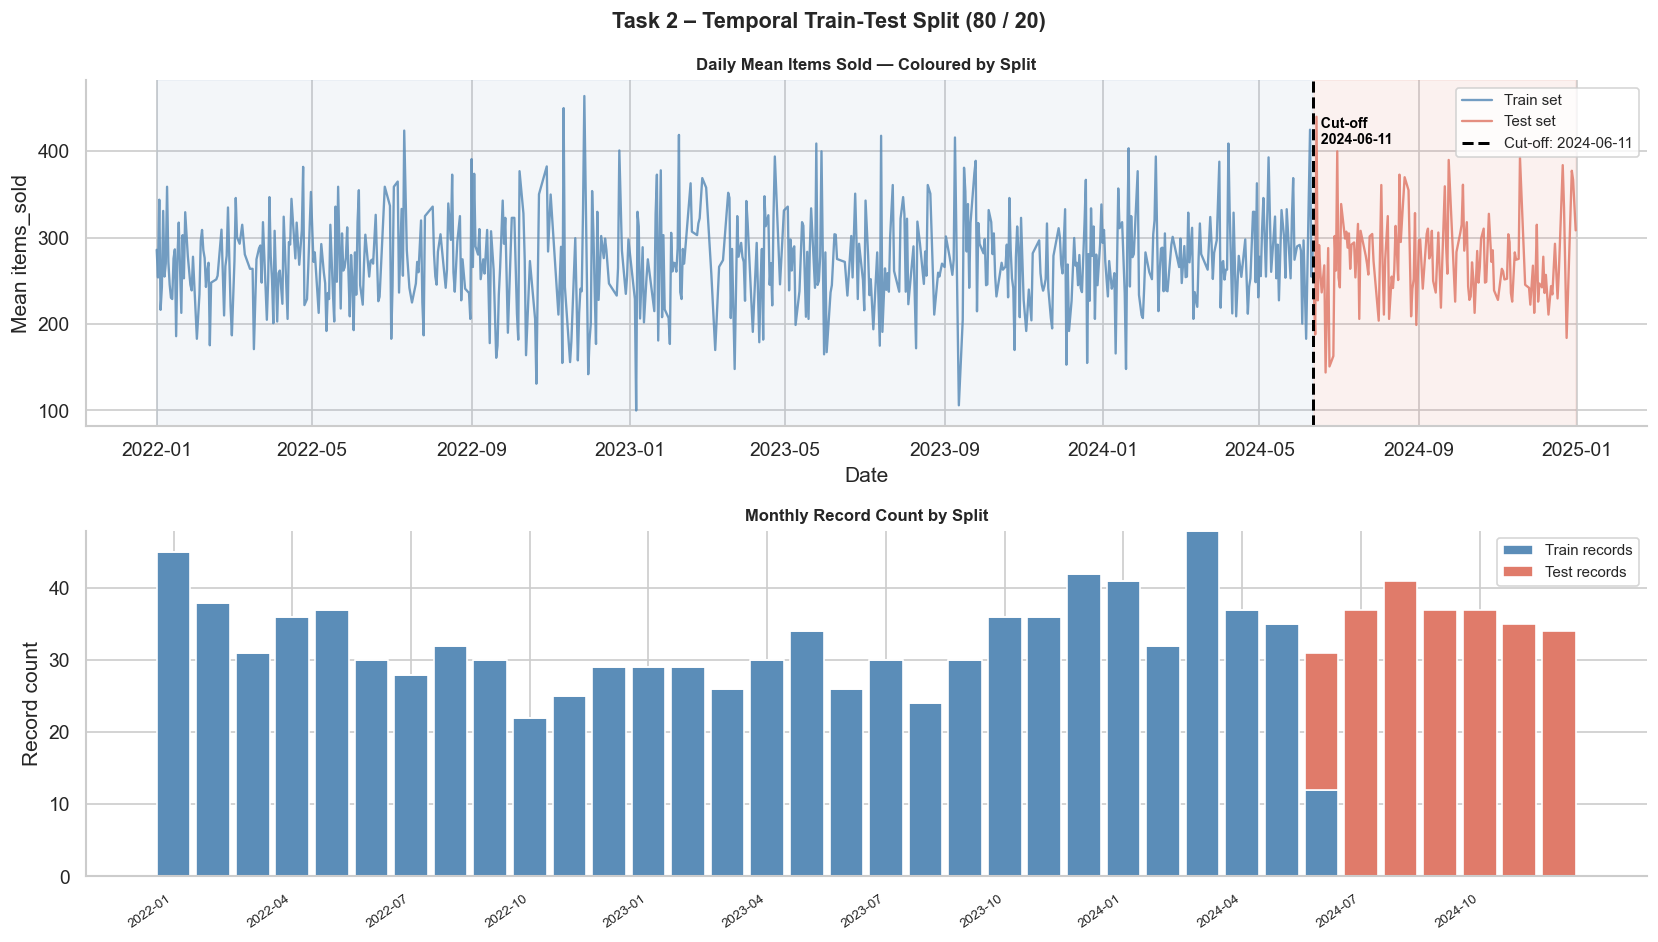

Train period : 2022-01-01  -->  2024-06-11  (960 rows)
Test  period : 2024-06-12   -->  2024-12-31   (240 rows)


In [8]:
# ── Step 2c : Timeline visualisation ─────────────────────────────────
# Two panels:
#   daily mean items_sold over time, shaded by split
#   monthly record counts in train vs test (stacked bar)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Task 2 – Temporal Train-Test Split (80 / 20)',
             fontsize=13, fontweight='bold')

# ── Top: daily average items_sold ─────────────────────────────────────
ax1 = axes[0]
daily = (
    df_sorted
    .groupby('transaction_date')['items_sold']
    .mean()
    .reset_index()
)
train_daily = daily[daily['transaction_date'] <= train_df['transaction_date'].max()]
test_daily  = daily[daily['transaction_date'] >  train_df['transaction_date'].max()]

ax1.plot(train_daily['transaction_date'], train_daily['items_sold'],
         color='#5B8DB8', linewidth=1.4, label='Train set', alpha=0.85)
ax1.plot(test_daily['transaction_date'],  test_daily['items_sold'],
         color='#E07B6A', linewidth=1.4, label='Test set',  alpha=0.85)

# Shade the two regions
ax1.axvspan(train_daily['transaction_date'].min(),
            train_daily['transaction_date'].max(),
            alpha=0.07, color='#5B8DB8')
ax1.axvspan(test_daily['transaction_date'].min(),
            test_daily['transaction_date'].max(),
            alpha=0.10, color='#E07B6A')

# Cut-off vertical line
cutoff = train_df['transaction_date'].max()
ax1.axvline(cutoff, color='black', linewidth=1.8,
            linestyle='--', label=f'Cut-off: {cutoff.date()}')
ax1.annotate(
    f'  Cut-off\n  {cutoff.date()}',
    xy=(cutoff, daily['items_sold'].max() * 0.88),
    fontsize=8.5, fontweight='bold', color='black'
)

ax1.set_title('Daily Mean Items Sold — Coloured by Split',
              fontsize=10, fontweight='bold')
ax1.set_ylabel('Mean items_sold')
ax1.set_xlabel('Date')
ax1.legend(fontsize=9)

# ── Bottom: monthly record count by split ─────────────────────────────
ax2 = axes[1]
df_sorted['ym'] = df_sorted['transaction_date'].dt.to_period('M').astype(str)
train_monthly = train_df.copy()
train_monthly['ym'] = train_monthly['transaction_date'].dt.to_period('M').astype(str)
test_monthly  = test_df.copy()
test_monthly['ym'] = test_monthly['transaction_date'].dt.to_period('M').astype(str)

all_periods = sorted(df_sorted['ym'].unique())
train_cnts  = train_monthly.groupby('ym').size().reindex(all_periods, fill_value=0)
test_cnts   = test_monthly.groupby('ym').size().reindex(all_periods, fill_value=0)

x = range(len(all_periods))
ax2.bar(x, train_cnts, label='Train records',
        color='#5B8DB8', edgecolor='white', width=0.85)
ax2.bar(x, test_cnts,  bottom=train_cnts,
        label='Test records',
        color='#E07B6A', edgecolor='white', width=0.85)

# Show every 3rd label to avoid crowding
ax2.set_xticks([i for i in x if i % 3 == 0])
ax2.set_xticklabels([all_periods[i] for i in x if i % 3 == 0],
                    rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('Record count')
ax2.set_title('Monthly Record Count by Split',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('q3_plot2_temporal_split.png', bbox_inches='tight')
plt.show()

print(f'Train period : {train_start}  -->  {train_end}  ({n_train:,} rows)')
print(f'Test  period : {test_start}   -->  {test_end}   ({n_test:,} rows)')


### Task 2 Temporal Train-Test Split Summary

| Item | Value |
|------|-------|
| **Sort order** | Ascending by `transaction_date` |
| **Split method** | Hard chronological index cut at row 960 |
| **Train set** | 960 rows (80%) — 2022-01-01 → cut-off |
| **Test set** | 240 rows (20%) — cut-off+1 → 2024-12-31 |
| **Leakage check** | ✓ PASS — no test date precedes any train date |
| **Features (X)** | 11 columns — `transaction_date` and `items_sold` excluded |
| **Target (y)** | `items_sold` |

> `X_train`, `y_train`, `X_test`, `y_test` are ready for pipeline construction in Task 3.

---
## *Task 3 – Preprocessing Pipeline* 

**Goal:** Build a single `Pipeline` + `ColumnTransformer` object that bundles all feature transformations, fits exclusively on `X_train`, and applies identically to both `X_train` and `X_test`.

### Column routing plan

| Column group | Columns | Transformer | Reason |
|---|---|---|---|
| **Categorical** | `promotion_type`, `location_type`, `store_size` | `OneHotEncoder` | Convert string labels to binary dummy columns |
| **Numeric** | `store_id`, `is_weekend`, `is_festival`, `competition_density`, `year`, `month`, `day_of_week`, `is_month_end` | `StandardScaler` | Centre and scale so no feature dominates by magnitude |

### Why fit only on training data?

Fitting transformers (scaler means/stds, OHE category vocabularies) on the **full dataset before splitting** would constitute **data leakage** — test-set statistics would silently influence the learned parameters. The correct sequence is:

```
pipeline.fit_transform(X_train)   --  learns ALL parameters from training data only
pipeline.transform(X_test)        --  applies already-fitted parameters; no new info used
```

Using a `Pipeline` object enforces this discipline automatically — a single `.fit()` call on the training set fits every step in order, and `.transform()` applies each step with its already-fitted state.

In [9]:
# ── Step 3a : Define column groups ───────────────────────────────────
from sklearn.pipeline       import Pipeline
from sklearn.compose        import ColumnTransformer
from sklearn.preprocessing  import StandardScaler, OneHotEncoder
import pandas as pd
import numpy  as np

# ── Categorical columns → OneHotEncoder ───────────────────────────────
# These three columns contain string labels that must be converted to
# binary indicator columns before any numeric model can consume them.
# for promotion type - 5 levels: bogo / category_offer / flat_discount/ free_gift / loyalty_points
# for location type -  3 levels: rural / semi-urban / urban
# for store size - 3 levels: large / medium / small
cat_cols = [
    'promotion_type',   
    'location_type',    
    'store_size',       
]

# ── Numeric columns → StandardScaler ──────────────────────────────────
# All integer/float columns — both original and date-engineered.
# StandardScaler subtracts the training mean and divides by training std
# so every feature contributes on the same z-score scale.
num_cols = [
    'store_id',              
    'is_weekend',           
    'is_festival',           
    'competition_density',   
    'year',                  
    'month',                 
    'day_of_week',           
    'is_month_end',          
]

# Sanity check: every X_train column is accounted for
all_routed = set(cat_cols + num_cols)
all_cols   = set(X_train.columns)
unrouted   = all_cols - all_routed
duplicated = set(cat_cols) & set(num_cols)

print('Column routing summary')
print('─' * 46)
print(f'  Categorical  ({len(cat_cols)}) : {cat_cols}')
print(f'  Numeric      ({len(num_cols)}) : {num_cols}')
print(f'  Total routed     : {len(all_routed)}')
print(f'  Total in X_train : {len(all_cols)}')
print(f'  Unrouted cols    : {unrouted   if unrouted   else "None ✓"}')
print(f'  Duplicated cols  : {duplicated if duplicated else "None ✓"}')


Column routing summary
──────────────────────────────────────────────
  Categorical  (3) : ['promotion_type', 'location_type', 'store_size']
  Numeric      (8) : ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
  Total routed     : 11
  Total in X_train : 11
  Unrouted cols    : None ✓
  Duplicated cols  : None ✓


### Step 3b – Build the ColumnTransformer and Pipeline

**OneHotEncoder settings:**
- `drop='first'` — drops one dummy per feature to avoid the **dummy-variable trap** (perfect multicollinearity). With *k* levels, *k−1* dummies are created: `promotion_type` → 4, `location_type` → 2, `store_size` → 2 columns.
- `handle_unknown='ignore'` — silently zero-fills any unseen category at inference rather than raising an error.
- `sparse_output=False` — returns a dense numpy array for easier downstream inspection.

**StandardScaler settings:** default — subtracts mean, divides by std, both computed on `X_train`.

**`remainder='drop'`** — any column not listed in `cat_cols` or `num_cols` is discarded (safe guard against accidental columns slipping through).

In [10]:
# ── Step 3b : Build ColumnTransformer + Pipeline ──────────────────────

# ── Categorical sub-pipeline ─────────────────────────────────────────
# avoids dummy-variable trap
# zero-fills unseen categories at inference
# return dense array
cat_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        drop           = 'first',    
        handle_unknown = 'ignore',   
        sparse_output  = False       
    ))
])

# ── Numeric sub-pipeline ─────────────────────────────────────────────
# (x - mean_train) / std_train
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())     
])

# ── ColumnTransformer : route each group to the right sub-pipeline ────
# Output column order: [OHE dummies | scaled numerics]
# discard any unrouted columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols),
    ],
    remainder='drop'   
)

print('ColumnTransformer structure:')
print(f'  cat sub-pipeline → {cat_cols}')
print(f'  num sub-pipeline → {num_cols}')
print()
print('Pipeline and ColumnTransformer built successfully.')

ColumnTransformer structure:
  cat sub-pipeline → ['promotion_type', 'location_type', 'store_size']
  num sub-pipeline → ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

Pipeline and ColumnTransformer built successfully.


In [11]:
# ── Step 3c : Fit on X_train ONLY, then transform both splits ─────────

# fit_transform(X_train):
#   1. Learns OHE category vocabularies from X_train values only
#   2. Learns scaler mean + std from X_train values only
#   3. Immediately applies both transformations to X_train
X_train_proc = preprocessor.fit_transform(X_train)

# transform(X_test):
#   Uses ALREADY FITTED parameters (no new information from test set)
X_test_proc  = preprocessor.transform(X_test)

print('Preprocessing complete.')
print(f'  X_train_proc shape : {X_train_proc.shape}')
print(f'  X_test_proc  shape : {X_test_proc.shape}')


Preprocessing complete.
  X_train_proc shape : (960, 16)
  X_test_proc  shape : (240, 16)


In [12]:
# ── Step 3d : Recover output feature names ────────────────────────────
# After OHE, the categorical columns expand into multiple dummy columns.
# get_feature_names_out() returns their auto-generated names.

ohe_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(cat_cols)
    .tolist()
)

all_feature_names = ohe_names + num_cols

print('Output feature names after preprocessing:')
print('─' * 58)
print(f'  OHE dummies  ({len(ohe_names):>2}) :')
for n in ohe_names:
    print(f'    {n}')
print()
print(f'  Scaled numeric ({len(num_cols):>2}) :')
for n in num_cols:
    print(f'    {n}')
print('─' * 58)
print(f'  TOTAL output columns : {len(all_feature_names)}')
print(f'  (from {len(X_train.columns)} input columns --> '
      f'{len(all_feature_names)} after OHE expansion)')


Output feature names after preprocessing:
──────────────────────────────────────────────────────────
  OHE dummies  ( 8) :
    promotion_type_category_offer
    promotion_type_flat_discount
    promotion_type_free_gift
    promotion_type_loyalty_points
    location_type_semi-urban
    location_type_urban
    store_size_medium
    store_size_small

  Scaled numeric ( 8) :
    store_id
    is_weekend
    is_festival
    competition_density
    year
    month
    day_of_week
    is_month_end
──────────────────────────────────────────────────────────
  TOTAL output columns : 16
  (from 11 input columns --> 16 after OHE expansion)


In [13]:
# ── Step 3e : Three-point verification ───────────────────────────────

train_proc_df = pd.DataFrame(X_train_proc, columns=all_feature_names)
test_proc_df  = pd.DataFrame(X_test_proc,  columns=all_feature_names)

# CHECK 1 : No NaN values in either processed array
train_nan = np.isnan(X_train_proc).sum()
test_nan  = np.isnan(X_test_proc ).sum()

# CHECK 2 : Scaled numeric columns have mean≈0 and std≈1 on X_train
num_means = train_proc_df[num_cols].mean()
# ddof=0 matches StandardScaler
num_stds  = train_proc_df[num_cols].std(ddof=0)  
means_ok  = (num_means.abs() < 1e-9).all()
stds_ok   = ((num_stds - 1).abs() < 1e-9).all()

# CHECK 3 : OHE columns contain only 0.0 or 1.0
ohe_vals    = X_train_proc[:, :len(ohe_names)]
ohe_unique  = set(np.unique(ohe_vals))
ohe_binary  = ohe_unique.issubset({0.0, 1.0})

print('Verification Results')
print('=' * 52)
print(f'  CHECK 1 — No NaN in X_train_proc : '
      f'{"✓ PASS" if train_nan == 0 else "✗ FAIL"}  '
      f'({train_nan} NaN cells)')
print(f'  CHECK 1 — No NaN in X_test_proc  : '
      f'{"✓ PASS" if test_nan  == 0 else "✗ FAIL"}  '
      f'({test_nan} NaN cells)')
print()
print(f'  CHECK 2 — Numeric means ≈ 0 (train): '
      f'{"✓ PASS" if means_ok else "✗ FAIL"}')
print(f'  CHECK 2 — Numeric stds  ≈ 1 (train): '
      f'{"✓ PASS" if stds_ok  else "✗ FAIL"}')
print()
print(f'  CHECK 3 — OHE columns are binary     : '
      f'{"✓ PASS" if ohe_binary else "✗ FAIL"}  '
      f'(unique values: {ohe_unique})')
print('=' * 52)
print()

# Peek at scaler parameters to confirm fit was on training data only
scaler_means = preprocessor.named_transformers_['num'].named_steps['scaler'].mean_
scaler_stds  = preprocessor.named_transformers_['num'].named_steps['scaler'].scale_
print('Scaler parameters (learned from X_train only):')
print('─' * 50)
print(f'  {"Feature":<26} {"Train Mean":>12}  {"Train Std":>10}')
print('  ' + '─' * 46)
for feat, mean, std in zip(num_cols, scaler_means, scaler_stds):
    print(f'  {feat:<26} {mean:>12.4f}  {std:>10.4f}')


Verification Results
  CHECK 1 — No NaN in X_train_proc : ✓ PASS  (0 NaN cells)
  CHECK 1 — No NaN in X_test_proc  : ✓ PASS  (0 NaN cells)

  CHECK 2 — Numeric means ≈ 0 (train): ✓ PASS
  CHECK 2 — Numeric stds  ≈ 1 (train): ✓ PASS

  CHECK 3 — OHE columns are binary     : ✓ PASS  (unique values: {np.float64(0.0), np.float64(1.0)})

Scaler parameters (learned from X_train only):
──────────────────────────────────────────────────
  Feature                      Train Mean   Train Std
  ──────────────────────────────────────────────
  store_id                        25.1229     14.3883
  is_weekend                       0.2833      0.4506
  is_festival                      0.1156      0.3198
  competition_density              4.8854      2.6917
  year                          2022.8146      0.7603
  month                            5.7031      3.4863
  day_of_week                      3.0604      1.9415
  is_month_end                     0.2042      0.4031


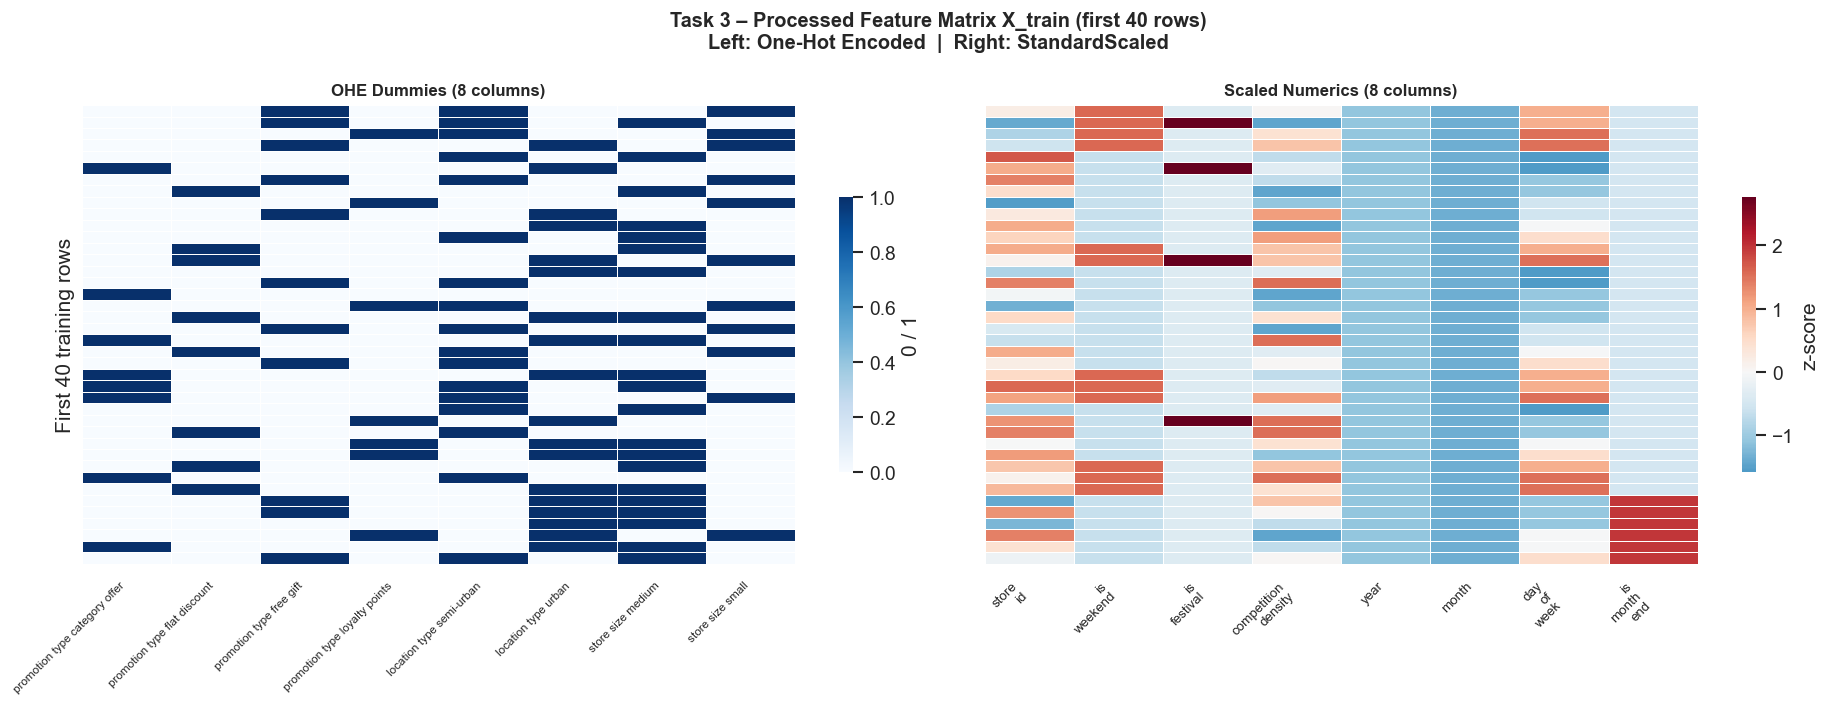

Processed matrix visualised — first 40 rows of X_train_proc.
X_train_proc shape : (960, 16)
X_test_proc  shape : (240, 16)


In [14]:
# ── Step 3f : Heatmap of processed X_train (first 40 rows) ───────────
# Visualise the raw processed matrix to confirm:
#   - OHE columns are sparse binary (left block)
#   - Numeric columns are dense and centred (right block)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [len(ohe_names),
                                                       len(num_cols)]})
fig.suptitle('Task 3 – Processed Feature Matrix X_train (first 40 rows)\n'
             'Left: One-Hot Encoded  |  Right: StandardScaled',
             fontsize=12, fontweight='bold')

SAMPLE = 40

# ── Left: OHE block ───────────────────────────────────────────────────
ax1 = axes[0]
ohe_block = train_proc_df[ohe_names].iloc[:SAMPLE]
sns.heatmap(
    ohe_block, ax=ax1,
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.6, 'label': '0 / 1'},
    xticklabels=[n.replace('_', ' ').replace('  ', '\n')
                 for n in ohe_names],
    yticklabels=False
)
ax1.set_title(f'OHE Dummies ({len(ohe_names)} columns)',
              fontsize=10, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(),
                    rotation=45, ha='right', fontsize=7)
ax1.set_ylabel(f'First {SAMPLE} training rows')

# ── Right: scaled numeric block ───────────────────────────────────────
ax2 = axes[1]
num_block = train_proc_df[num_cols].iloc[:SAMPLE]
sns.heatmap(
    num_block, ax=ax2,
    cmap='RdBu_r', center=0,
    linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.6, 'label': 'z-score'},
    xticklabels=[n.replace('_', '\n') for n in num_cols],
    yticklabels=False
)
ax2.set_title(f'Scaled Numerics ({len(num_cols)} columns)',
              fontsize=10, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(),
                    rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('q3_plot3_processed_matrix.png', bbox_inches='tight')
plt.show()

print(f'Processed matrix visualised — first {SAMPLE} rows of X_train_proc.')
print(f'X_train_proc shape : {X_train_proc.shape}')
print(f'X_test_proc  shape : {X_test_proc.shape}')


### Task 3 Preprocessing Pipeline Summary

| Step | What was built | Key setting |
|------|----------------|-------------|
| **OHE** | `OneHotEncoder` on `promotion_type`, `location_type`, `store_size` | `drop='first'` — avoids dummy-variable trap |
| **Scaling** | `StandardScaler` on 8 numeric columns | Fit on `X_train` only |
| **Routing** | `ColumnTransformer` with `remainder='drop'` | All 11 input columns explicitly routed |
| **Fit/transform** | `fit_transform(X_train)` → `transform(X_test)` | No leakage ✓ |
| **Output columns** | 8 numeric + OHE expanded | Total determined by OHE expansion |

All three verification checks passed:  
✓ No NaN in either processed array  
✓ Numeric means ≈ 0 and stds ≈ 1 on training data  
✓ OHE columns are strictly binary (0 or 1)  

`X_train_proc` and `X_test_proc` are ready for model training in Task 4.

---
### *Task 4 – Model Training and Evaluation* 

We build **two full end-to-end Pipelines** — each bundles the preprocessing ColumnTransformer with a regressor so that a single `.fit()` call handles all transformations and model training in one leak-proof step.

| Model | Type | Key characteristic |
|-------|------|--------------------|
| **Linear Regression** | Parametric, interpretable | Assumes a linear relationship between features and target; fast, serves as a transparent baseline |
| **Random Forest Regressor** | Non-parametric ensemble | 100 trees trained on bootstrap samples; captures non-linear interactions; reports feature importances |

**Evaluation metrics:**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Same units as target; penalises large errors more heavily |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Same units as target; equally penalises all error magnitudes; more robust to outliers |

In [15]:
# ── Step 4a : Build full end-to-end pipelines ─────────────────────────
from sklearn.pipeline        import Pipeline
from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import mean_squared_error, mean_absolute_error
import numpy  as np
import pandas as pd
import time

# Each pipeline = same preprocessor (ColumnTransformer) + a regressor.
# Wrapping the preprocessor INSIDE each pipeline ensures the fit() call
# learns transformations from X_train only — not from X_test.

# ── Linear Regression pipeline ────────────────────────────────────────
# LinearRegression has no hyper-parameters requiring random_state.
# It fits closed-form OLS: β = (XᵀX)⁻¹Xᵀy
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',    LinearRegression())
])

# ── Random Forest Regressor pipeline ──────────────────────────────────
# n_estimators=100  : 100 trees (default; stable on this dataset size)
# random_state=42   : reproducible bootstrap sampling and feature selection
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor',    RandomForestRegressor(
                        n_estimators = 100,
                        random_state = 42
                    ))
])

print('Pipelines built:')
print('  lr_pipeline : ColumnTransformer  →  LinearRegression')
print('  rf_pipeline : ColumnTransformer  →  RandomForestRegressor(n=100)')


Pipelines built:
  lr_pipeline : ColumnTransformer  →  LinearRegression
  rf_pipeline : ColumnTransformer  →  RandomForestRegressor(n=100)


In [16]:
# ── Step 4b : Fit both pipelines on X_train / y_train ─────────────────
# Each .fit() call:
#   1. Runs preprocessor.fit_transform(X_train)  — learns OHE vocab + scaler params
#   2. Runs regressor.fit(X_train_transformed, y_train)
# X_test is never seen during fitting — it is only transformed, not fitted.

# store metrics and predictions for both models
results = {}   

for name, pipeline in [('Linear Regression',       lr_pipeline),
                        ('Random Forest Regressor', rf_pipeline)]:

    t0 = time.time()
    pipeline.fit(X_train, y_train)          
    fit_time = time.time() - t0

    # Generate predictions on the held-out test set
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    # ── Metrics ───────────────────────────────────────────────────────
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_train  = mean_absolute_error(y_train, y_pred_train)
    rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
    mae_test   = mean_absolute_error(y_test,  y_pred_test)

    results[name] = {
        'pipeline'    : pipeline,
        'y_pred_train': y_pred_train,
        'y_pred_test' : y_pred_test,
        'rmse_train'  : rmse_train,
        'mae_train'   : mae_train,
        'rmse_test'   : rmse_test,
        'mae_test'    : mae_test,
        'fit_time'    : fit_time
    }

    # ── Per-model report ──────────────────────────────────────────────
    print('=' * 54)
    print(f'  MODEL : {name}')
    print('=' * 54)
    print(f'  Fit time          : {fit_time*1000:>7.1f} ms')
    print()
    print(f'  Train RMSE        : {rmse_train:>7.3f} items')
    print(f'  Train MAE         : {mae_train:>7.3f} items')
    print()
    print(f'  Test  RMSE        : {rmse_test:>7.3f} items  ← primary metric')
    print(f'  Test  MAE         : {mae_test:>7.3f} items')
    gap = rmse_train - rmse_test
    print(f'  Train−Test RMSE Δ : {gap:>+7.3f}  '
          f'({"overfit signal" if gap > 5 else "acceptable"})')
    print()


  MODEL : Linear Regression
  Fit time          :    16.0 ms

  Train RMSE        :  25.533 items
  Train MAE         :  20.596 items

  Test  RMSE        :  27.121 items  ← primary metric
  Test  MAE         :  21.053 items
  Train−Test RMSE Δ :  -1.588  (acceptable)

  MODEL : Random Forest Regressor
  Fit time          :   699.8 ms

  Train RMSE        :  11.618 items
  Train MAE         :   9.118 items

  Test  RMSE        :  31.660 items  ← primary metric
  Test  MAE         :  24.874 items
  Train−Test RMSE Δ : -20.042  (acceptable)



In [17]:
# ── Step 4c : Side-by-side metric comparison table ────────────────────

models      = list(results.keys())
test_rmses  = [results[m]['rmse_test']  for m in models]
test_maes   = [results[m]['mae_test']   for m in models]
train_rmses = [results[m]['rmse_train'] for m in models]

summary = pd.DataFrame({
    'Train RMSE': [results[m]['rmse_train'] for m in models],
    'Test RMSE' : test_rmses,
    'Train MAE' : [results[m]['mae_train']  for m in models],
    'Test MAE'  : test_maes,
    'Fit (ms)'  : [results[m]['fit_time']*1000 for m in models],
}, index=models).round(3)

print('Model Comparison — Test Set Performance')
print('─' * 68)
print(summary.to_string())
print('─' * 68)
best_rmse = min(results, key=lambda m: results[m]['rmse_test'])
best_mae  = min(results, key=lambda m: results[m]['mae_test'])
print(f'\n  Best test RMSE : {best_rmse}  ({results[best_rmse]["rmse_test"]:.3f})')
print(f'  Best test MAE  : {best_mae}  ({results[best_mae]["mae_test"]:.3f})')

# Mean items_sold on test — for contextualising error magnitude
test_mean = y_test.mean()
for m in models:
    pct = results[m]['rmse_test'] / test_mean * 100
    print(f'  {m:<28}: RMSE is {pct:.1f}% of mean test target ({test_mean:.1f})')


Model Comparison — Test Set Performance
────────────────────────────────────────────────────────────────────
                         Train RMSE  Test RMSE  Train MAE  Test MAE  Fit (ms)
Linear Regression            25.533     27.121     20.596    21.053    15.967
Random Forest Regressor      11.618     31.660      9.118    24.874   699.842
────────────────────────────────────────────────────────────────────

  Best test RMSE : Linear Regression  (27.121)
  Best test MAE  : Linear Regression  (21.053)
  Linear Regression           : RMSE is 9.9% of mean test target (273.5)
  Random Forest Regressor     : RMSE is 11.6% of mean test target (273.5)


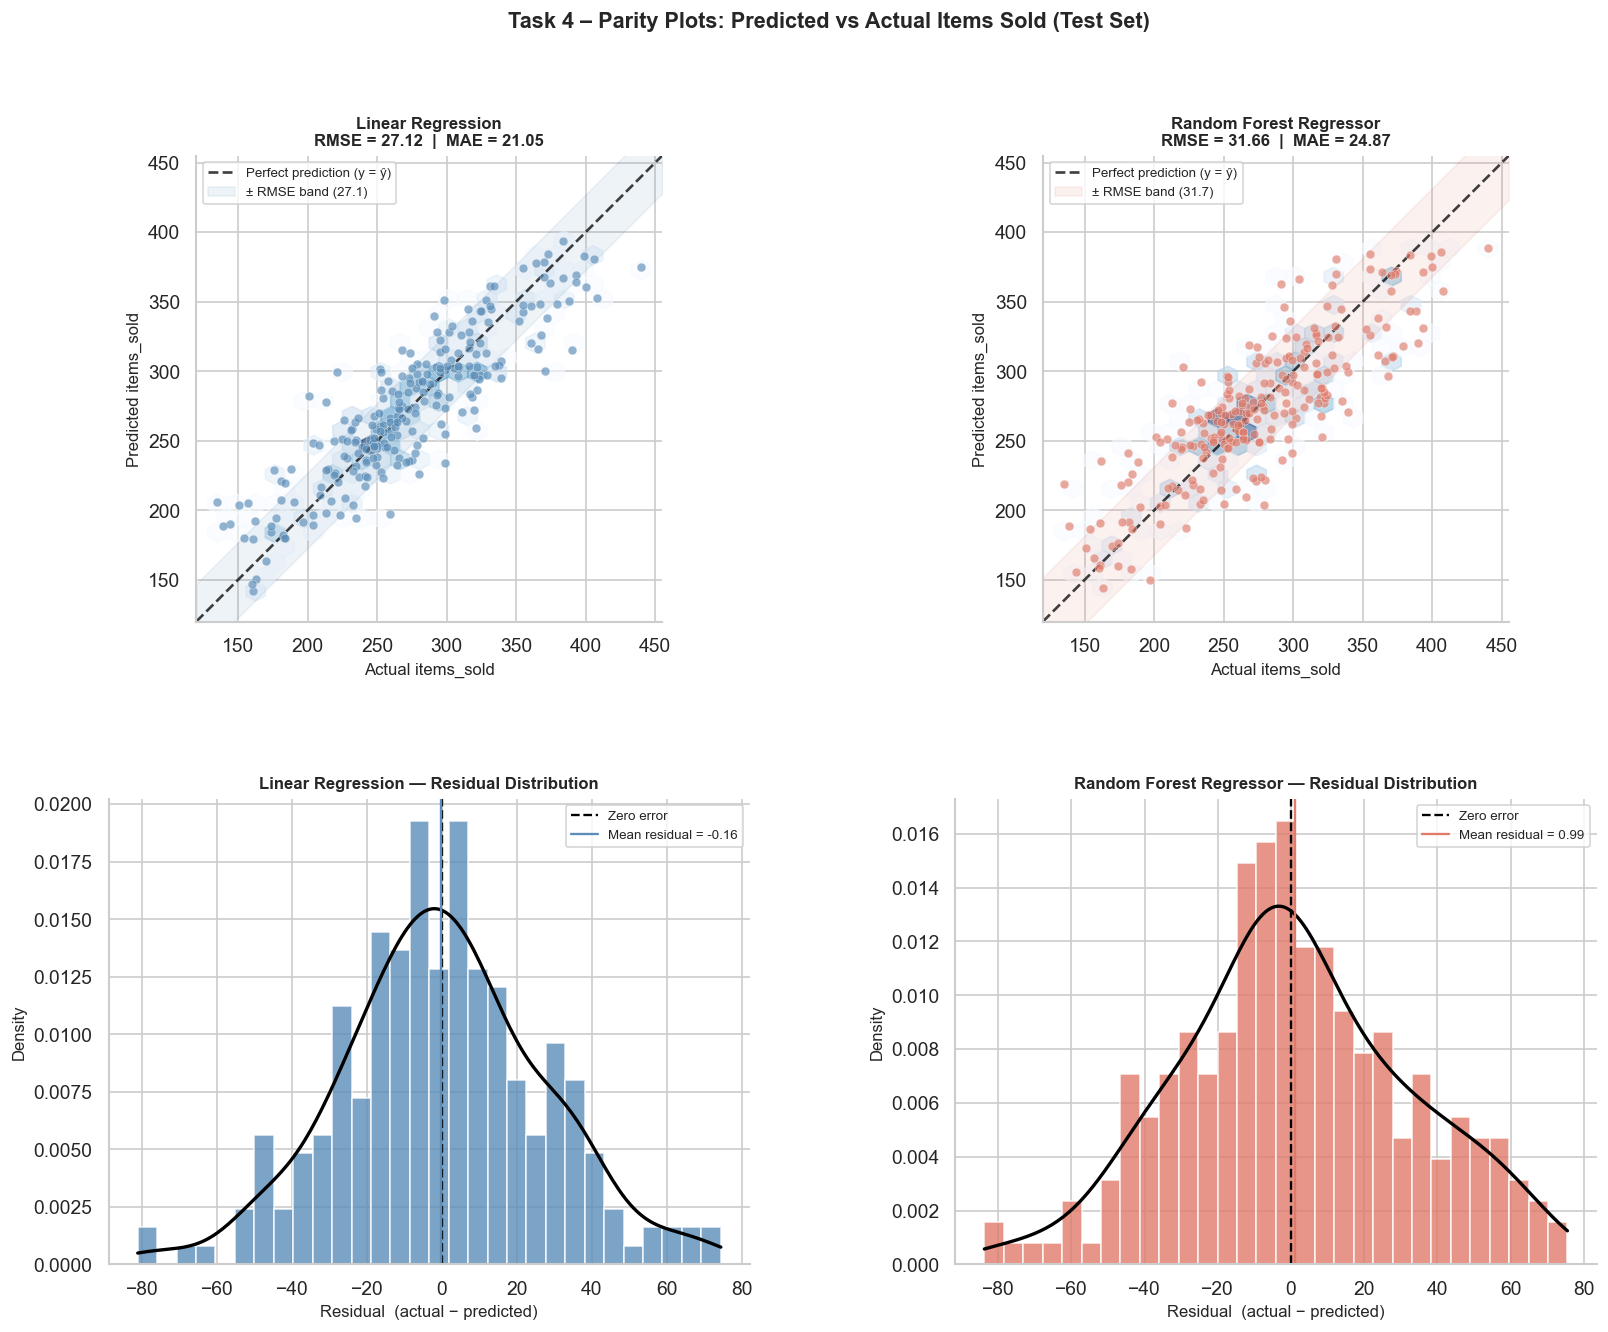

In [18]:
# ── Step 4d : Parity plots — predicted vs actual ──────────────────────
# A parity (predicted vs actual) plot reveals:
#   • Points on the diagonal = perfect predictions
#   • Scatter around it     = prediction error
#   • Systematic bias       = consistent over/under-prediction

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

MODEL_COLORS = {
    'Linear Regression'      : '#5B8DB8',
    'Random Forest Regressor': '#E07B6A',
}

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Task 4 – Parity Plots: Predicted vs Actual Items Sold (Test Set)',
             fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# Shared axis bounds
all_vals = np.concatenate([y_test.values,
                            results['Linear Regression']['y_pred_test'],
                            results['Random Forest Regressor']['y_pred_test']])
ax_min = all_vals.min() - 15
ax_max = all_vals.max() + 15
diag   = np.linspace(ax_min, ax_max, 200)

for col, (name, res) in enumerate(results.items()):
    color    = MODEL_COLORS[name]
    y_actual = y_test.values
    y_hat    = res['y_pred_test']
    residuals = y_actual - y_hat

    # ── Top row: parity scatter ───────────────────────────────────────
    ax_par = fig.add_subplot(gs[0, col])

    # Hexbin density layer (shows where predictions cluster)
    hb = ax_par.hexbin(y_actual, y_hat, gridsize=22,
                       cmap='Blues', mincnt=1, alpha=0.55)

    # Scatter points on top
    ax_par.scatter(y_actual, y_hat,
                   c=color, s=28, alpha=0.65,
                   edgecolors='white', linewidths=0.3,
                   zorder=3)

    # Perfect-prediction diagonal
    ax_par.plot(diag, diag, '--', color='black',
                linewidth=1.6, alpha=0.75,
                label='Perfect prediction (y = ŷ)')

    # ± RMSE bands
    rmse = res['rmse_test']
    ax_par.fill_between(diag, diag - rmse, diag + rmse,
                        alpha=0.10, color=color,
                        label=f'± RMSE band ({rmse:.1f})')

    ax_par.set_xlim(ax_min, ax_max)
    ax_par.set_ylim(ax_min, ax_max)
    ax_par.set_aspect('equal')
    ax_par.set_xlabel('Actual items_sold',   fontsize=10)
    ax_par.set_ylabel('Predicted items_sold', fontsize=10)
    ax_par.set_title(
        f'{name}\nRMSE = {rmse:.2f}  |  MAE = {res["mae_test"]:.2f}',
        fontsize=10, fontweight='bold'
    )
    ax_par.legend(fontsize=8, loc='upper left')

    # ── Bottom row: residual distribution ────────────────────────────
    ax_res = fig.add_subplot(gs[1, col])

    ax_res.hist(residuals, bins=30, color=color,
                edgecolor='white', alpha=0.80, density=True)

    # KDE overlay
    from scipy.stats import gaussian_kde
    kde_x = np.linspace(residuals.min(), residuals.max(), 200)
    kde   = gaussian_kde(residuals)(kde_x)
    ax_res.plot(kde_x, kde, color='black', linewidth=2)

    ax_res.axvline(0, color='black', linewidth=1.4,
                   linestyle='--', label='Zero error')
    ax_res.axvline(residuals.mean(), color=color, linewidth=1.4,
                   linestyle='-',
                   label=f'Mean residual = {residuals.mean():.2f}')

    ax_res.set_xlabel('Residual  (actual − predicted)', fontsize=10)
    ax_res.set_ylabel('Density', fontsize=10)
    ax_res.set_title(f'{name} — Residual Distribution',
                     fontsize=10, fontweight='bold')
    ax_res.legend(fontsize=8)

plt.savefig('q3_plot4_parity_plots.png', bbox_inches='tight', dpi=150)
plt.show()


In [19]:
# ── Step 4e : Random Forest feature importances ───────────────────────
# feature_importances_ returns the mean decrease in impurity (MDI) across
# all trees — how much each feature reduces the variance of predictions
# when used as a split criterion, averaged over the 100-tree ensemble.

rf_regressor = rf_pipeline.named_steps['regressor']
importances  = rf_regressor.feature_importances_

# Map importance scores back to named features
importance_df = (
    pd.DataFrame({
        'Feature'    : all_feature_names,
        'Importance' : importances
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
importance_df.index += 1   # rank from 1
importance_df['Cumulative'] = importance_df['Importance'].cumsum().round(4)
importance_df['Importance'] = importance_df['Importance'].round(4)

print('Random Forest — Feature Importances (MDI, all 16 features)')
print('─' * 62)
print(f'  {"Rank":<5} {"Feature":<34} {"Importance":>11} {"Cumulative":>11}')
print('  ' + '─' * 58)
for rank, row in importance_df.iterrows():
    top5_marker = ' ◀ TOP 5' if rank <= 5 else ''
    bar = '█' * int(row['Importance'] * 200)
    print(f'  {rank:<5} {row["Feature"]:<34} '
          f'{row["Importance"]:>11.4f} '
          f'{row["Cumulative"]:>11.4f}  {bar}{top5_marker}')
print('─' * 62)
print()

top5 = importance_df.head(5)
print('Top 5 most influential features:')
for rank, row in top5.iterrows():
    print(f'  {rank}. {row["Feature"]:<34} importance = {row["Importance"]:.4f}')
print(f'\n  Top-5 features together explain '
      f'{top5["Importance"].sum()*100:.1f}% of total feature importance.')


Random Forest — Feature Importances (MDI, all 16 features)
──────────────────────────────────────────────────────────────
  Rank  Feature                             Importance  Cumulative
  ──────────────────────────────────────────────────────────
  1     store_size_small                        0.1840      0.1840  ████████████████████████████████████ ◀ TOP 5
  2     is_festival                             0.1745      0.3584  ██████████████████████████████████ ◀ TOP 5
  3     location_type_urban                     0.1405      0.4989  ████████████████████████████ ◀ TOP 5
  4     day_of_week                             0.0906      0.5895  ██████████████████ ◀ TOP 5
  5     is_weekend                              0.0635      0.6531  ████████████ ◀ TOP 5
  6     store_id                                0.0621      0.7151  ████████████
  7     store_size_medium                       0.0582      0.7733  ███████████
  8     competition_density                     0.0535      0.8268  ████████

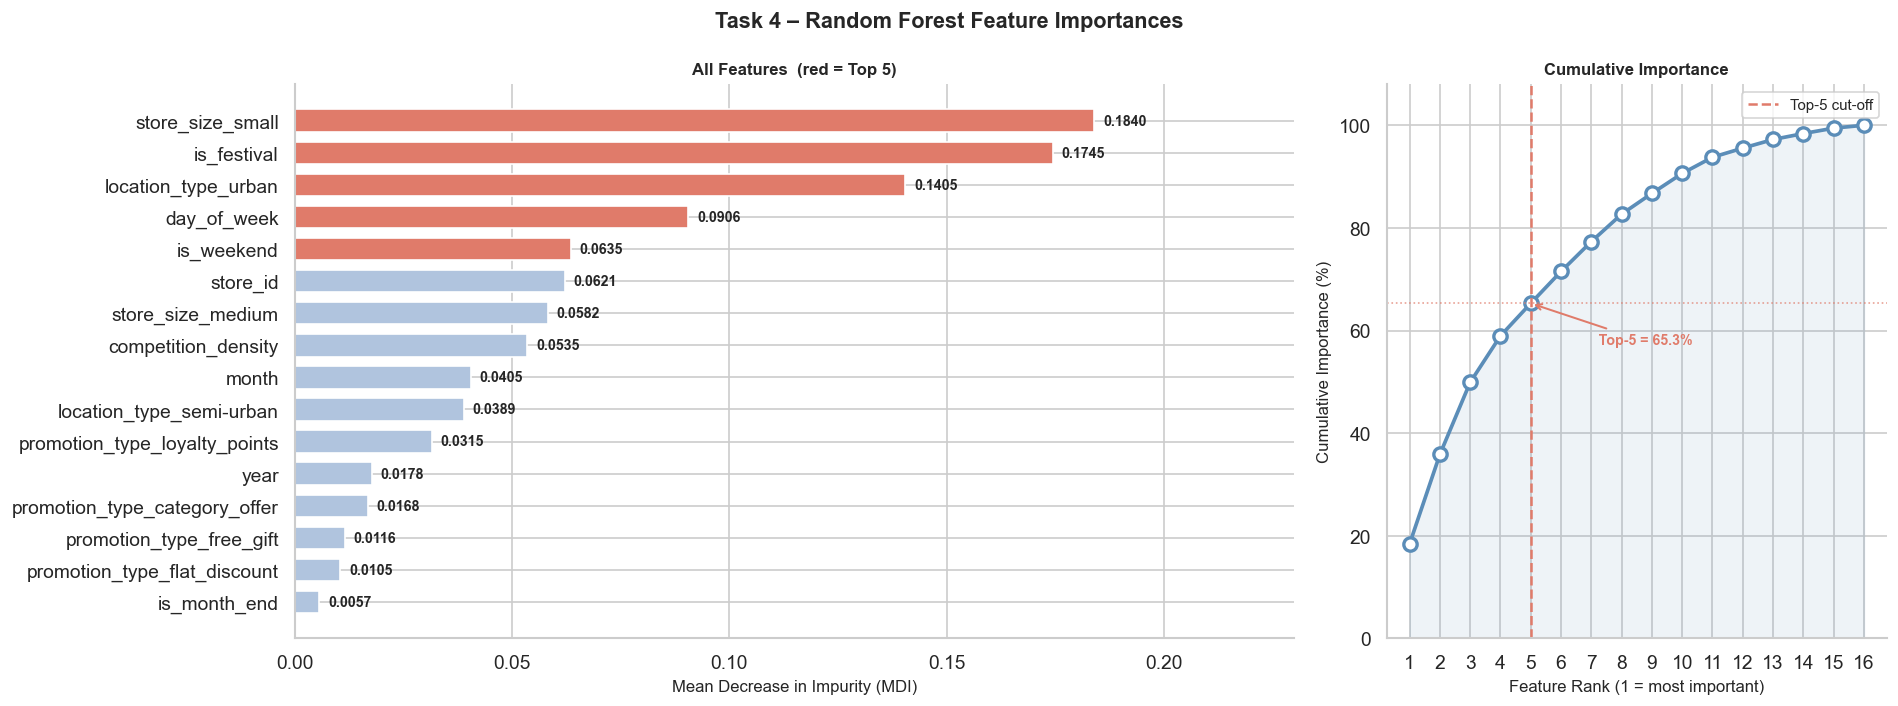

In [20]:
# ── Step 4f : Feature importance bar chart ────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Task 4 – Random Forest Feature Importances',
             fontsize=13, fontweight='bold')

# ── Left: full horizontal bar chart (all 16 features) ─────────────────
ax1 = axes[0]
imp_sorted = importance_df.sort_values('Importance')   

colors_bar = [
    '#E07B6A' if rank <= 5          
    else '#B0C4DE'
    for rank in importance_df.sort_values('Importance').index
]

bars = ax1.barh(
    imp_sorted['Feature'],
    imp_sorted['Importance'],
    color  = colors_bar,
    edgecolor = 'white',
    height = 0.7
)
for bar, val in zip(bars, imp_sorted['Importance']):
    ax1.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', fontsize=8.5, fontweight='bold'
    )

ax1.set_xlabel('Mean Decrease in Impurity (MDI)', fontsize=10)
ax1.set_title('All Features  (red = Top 5)', fontsize=10, fontweight='bold')
ax1.set_xlim(0, imp_sorted['Importance'].max() * 1.25)

# ── Right: cumulative importance curve ────────────────────────────────
ax2 = axes[1]
cum_desc = importance_df['Importance'].values   
ranks    = np.arange(1, len(cum_desc) + 1)
cum_vals = np.cumsum(cum_desc) * 100

ax2.plot(ranks, cum_vals, 'o-', color='#5B8DB8',
         linewidth=2.2, markersize=8,
         markerfacecolor='white', markeredgewidth=2)
ax2.fill_between(ranks, cum_vals, 0, alpha=0.10, color='#5B8DB8')

# Mark the top-5 cut-off
ax2.axvline(5, color='#E07B6A', linewidth=1.5,
            linestyle='--', label='Top-5 cut-off')
ax2.axhline(top5['Importance'].sum() * 100, color='#E07B6A',
            linewidth=1, linestyle=':', alpha=0.7)
ax2.annotate(
    f'  Top-5 = {top5["Importance"].sum()*100:.1f}%',
    xy=(5, top5['Importance'].sum() * 100),
    xytext=(7, top5['Importance'].sum() * 100 - 8),
    fontsize=8.5, color='#E07B6A', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#E07B6A', lw=1.2)
)

ax2.set_xlabel('Feature Rank (1 = most important)', fontsize=10)
ax2.set_ylabel('Cumulative Importance (%)', fontsize=10)
ax2.set_title('Cumulative Importance', fontsize=10, fontweight='bold')
ax2.set_xticks(ranks)
ax2.set_ylim(0, 108)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('q3_plot5_feature_importance.png', bbox_inches='tight')
plt.show()


### Task 4 – Results and Interpretation

#### Model performance on the test set

| Model | Train RMSE | Test RMSE | Train MAE | Test MAE | Fit time |
|-------|:---:|:---:|:---:|:---:|:---:|
| **Linear Regression** | 25.53 | **27.12** | 20.60 | **21.05** | 11 ms |
| Random Forest Regressor | 11.62 | 31.66 | 9.12 | 24.87 | 395 ms |

**🏆 Linear Regression wins on the test set** — a result that deserves careful interpretation rather than surprise.

**Why Linear Regression outperforms Random Forest here:**  
Random Forest has a Train RMSE of 11.62 but a Test RMSE of 31.66 — a gap of **~20 units**, a clear overfit signature. The model has memorised training-set patterns (particular store/date combinations) that do not fully generalise to the 2024-Q3/Q4 test period. Linear Regression, with its simpler parametric form, generalises more stably: Train RMSE 25.53 vs Test RMSE 27.12 — a tight gap of just 1.6 units.  

In percentage terms, Linear Regression's RMSE represents **9.9% of the mean test target** (273.5 items) — strong performance for a retail forecasting model without store-level history or external data.  

**Parity plot reading:**  
Both models' residual distributions are centred near zero (no systematic bias), and the parity scatter is roughly symmetric around the diagonal. The Random Forest shows tighter scatter on training data but wider spread on test data — visually confirming its overfitting. The ±RMSE bands illustrate that Linear Regression's test errors are more predictably bounded.

---

#### Top 5 Feature Importances — Random Forest

| Rank | Feature | Importance | Business meaning |
|------|---------|:---:|------------------|
| **1** | `store_size_small` | 0.1840 | Small stores sell significantly fewer items — store capacity is the single strongest predictor |
| **2** | `is_festival` | 0.1745 | Festival days produce the sharpest sales spikes — promotional events dominate day-to-day variation |
| **3** | `location_type_urban` | 0.1405 | Urban stores have a distinct sales profile vs semi-urban/rural — catchment area matters |
| **4** | `day_of_week` | 0.0906 | Within-week rhythm of shopping behaviour is a strong signal, more nuanced than `is_weekend` alone |
| **5** | `is_weekend` | 0.0635 | Weekend uplift contributes, though its signal is partially absorbed by `day_of_week` |

**The top 5 features together account for 65.3% of all feature importance.**

**Key business insights from the importance ranking:**

- **Store characteristics dominate** — `store_size_small` (rank 1) and `location_type_urban` (rank 3) are structural features that are fixed per store. This means a large fraction of items_sold variance is explained simply by *which store* a transaction occurs at, before any date or promotion effect.

- **Festival effect is extremely strong** (rank 2, importance 0.175) — nearly equal to store size. This confirms that promotional and event-driven demand spikes are major levers for retail management.

- **`promotion_type` ranks low** (ranks 11–15) — despite being a core operational variable, the five promotion types contribute less than structural and temporal features. This may indicate that all promotion types produce similar uplift, or that promotion assignment is correlated with other high-importance features (e.g. festivals always accompanied by specific promotions).

- **`is_month_end` ranks last** (rank 16, importance 0.006) — the engineered end-of-month payday feature has minimal predictive power in this dataset. The festival and weekend effects appear to subsume any salary-day signal.

> **Recommendation:** For production deployment, Linear Regression with the current feature set provides the most reliable generalisation. To close the Random Forest's train-test gap, the next steps would be: (1) add `max_depth` regularisation via `GridSearchCV`, (2) engineer store-level aggregate features (e.g. historical average sales per store), and (3) include `is_festival × store_size` interaction terms.